# Records Matching

DS 6105 | Summer 2026

**Know Their Names Capstone**

## Set Up

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb # Using this for joins
import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import display, HTML

In [2]:
con = duckdb.connect()

## Read

### MENTION

We import the mentions data, dropping all the super-low entropy columns, i.e. where only one value exists, or they are all nulls.

In [89]:
mention_file = "../data/sources/all_mentions.csv"
mention_cols_to_drop = ['original_data','created','county','narrative','maiden_name'] #'death_year','location_id','source_year','source'] 
MENTION = (
    pd.read_csv(mention_file, low_memory=False)
    .set_index('mention_id')
    .drop(mention_cols_to_drop, axis=1)
    .drop_duplicates()
)

MENTION['birth_year'] = MENTION.birth_year.astype('Int64')

## Define a Person Key that includes the enslavers last name for nameless enslaved

MENTION['enslaver_name'] = (
    MENTION.reset_index()
    .merge(MENTION.reset_index(), left_on='enslaver_id', right_on='mention_id')
).set_index('mention_id_x').full_name_y
MENTION['enslaver_name'].fillna("")

def make_key_str(x):
    person_str = (
        "-".join([str(v).lower() for v in x[:-1]])
        .replace(" ","_")
        .replace("nan","X")
        .replace("<na>","XXXX")
    )
    if not pd.isna(x.enslaver_name):
        person_str += f"-enslaver:{x.enslaver_name.lower().replace(" ", "_")}"
    return person_str
    
key_cols = ['birth_year', 'norm_race', 'gender', 'full_name','enslaver_name']
MENTION['person_key'] = MENTION[key_cols].apply(make_key_str, axis=1)

_ = con.register('mention', MENTION.reset_index())

In [ ]:
COLS = MENTION.info().to_frame()

<class 'pandas.DataFrame'>
Index: 86825 entries, a632802a-a920-4a60-b231-504c103e1bbe to 6f244ce8-7286-4008-9e08-8973e05f38be
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   source            86825 non-null  str    
 1   source_year       86825 non-null  int64  
 2   confidence        86825 non-null  float64
 3   full_name         79288 non-null  str    
 4   first_name        77705 non-null  str    
 5   middle_name       24070 non-null  str    
 6   last_name         78507 non-null  str    
 7   birth_year        75457 non-null  Int64  
 8   death_year        1604 non-null   float64
 9   race              71590 non-null  str    
 10  gender            78903 non-null  str    
 11  occupation        39124 non-null  str    
 12  legal_status      67330 non-null  str    
 13  is_enslaver       79723 non-null  str    
 14  norm_first_name   77689 non-null  str    
 15  nysiis_last_name  78505 non-null  str

### ASSERTION

In [ ]:
assertion_file = "../data/sources/all_assertions.csv"
assertion_cols_to_drop = ['created','object_string','county']
# ASSERTION = (
#     pd.read_csv(assertion_file, low_memory=False)
#     .set_index(['predicate', 'object_id', 'subject_id'])
#     .drop(assertion_cols_to_drop, axis=1)
#     .drop_duplicates()
# )


In [ ]:
ASSERTION = (
    pd.read_csv(assertion_file, low_memory=False)
    .drop(assertion_cols_to_drop, axis=1)
    .drop_duplicates()
    .merge(MENTION.reset_index(), left_on='subject_id', right_on='mention_id')
    .merge(MENTION.reset_index(), left_on='object_id', right_on='mention_id')
)
# ASSERTION

In [ ]:
_ = con.register('assertion', ASSERTION.reset_index());

## Transform

In [6]:
PERSON = MENTION.value_counts('person_key').to_frame('n_mentions')
PERSON['mention_ids'] = MENTION.reset_index().groupby('person_key').mention_id.apply(lambda x: list(x))
PERSON['all_same'] = None
_ = con.register('person', PERSON.reset_index())

In [7]:
PERSON.sample(10)

,n_mentions,mention_ids,all_same
person_key,,,
1875-w-m-john_mcdonald,1,[2794452f-dc47-45b6-ae38-a12ae6187c03],None
XXXX-X-X-wm_a_bibbee,1,[d8defcee-4ae0-4991-ab2f-ad5b70f3e1c1],None
1869-w-f-bettie_a_parrish,1,[d8b2ff5f-faed-4c05-84ee-f4e68fce8324],None
1845-b-f-annie_evans,1,[60a85dad-cedc-40a0-88cd-13560ee256f1],None
1868-w-f-susan_jane_cale,1,[c0213e60-4ed0-43a7-9cca-1ebd263a388a],None
1871-w-f-alice_b_towberman,1,[c070e809-2b82-4a34-970a-2162c97d66a4],None
1844-w-f-susan_c_meeks,1,[ac56fa2a-307b-4edc-b3f2-d05e62d11e08],None
1857-w-m-samuel_strickler,1,[bd714875-e77b-42aa-82e7-deab2ac94565],None
1872-w-f-alice_okeefe,1,[4ee04cb7-f730-4d41-89f1-226c9ce67fe1],None


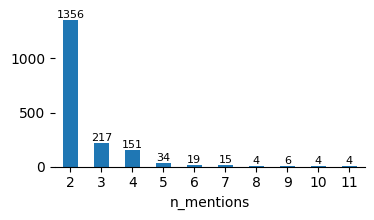

In [80]:
ax = PERSON[PERSON.n_mentions > 1].n_mentions.value_counts().sort_index().head(10).plot.bar(figsize=(4,2), rot=0)
ax.bar_label(ax.containers[0], fontsize=8)
sns.despine(left=True)
plt.show()

### Join MENTION and ASSERTION

In [11]:
con.sql("""
CREATE OR REPLACE VIEW assertion_v AS
SELECT m1.person_key AS 'subject_key', predicate, m2.person_key AS 'object_key', a.subject_id, a.object_id
    FROM assertion a 
        JOIN mention m1 ON m1.mention_id = a.subject_id
        JOIN mention m2 ON m2.mention_id = a.object_id
""")
A = con.sql("select * from assertion_v").df()

In [12]:
A.sort_values('subject_key')

,subject_key,predicate,object_key,subject_id,object_id
59030,1750-b-f-X-enslaver:john_j_bowcock,wasEnslavedBy,XXXX-X-X-john_j_bowcock,c9726eff-befc-4de2-9131-9d30419a0e72,3828e268-f536-4102-8b14-bac0172cb170
56560,1750-b-f-X-enslaver:william_rothwell,wasEnslavedBy,XXXX-X-X-william_rothwell,d20ff507-09ed-48d0-b4db-beb616f9b8b1,aaa46f22-9e31-4391-ae3f-ef37159fa7a0
57598,1750-b-m-X-enslaver:colvin_cradock,wasEnslavedBy,XXXX-X-X-colvin_cradock,847038d8-a520-4ef2-81f9-d111bdb201c4,c4a62f0e-31b9-497d-88d3-409c4adb36f5
56093,1760-b-f-X-enslaver:edwin_douglas,wasEnslavedBy,XXXX-X-X-edwin_douglas,68d217ee-a516-4f14-9500-7d99181329fa,b3f91fa0-dddf-4d51-96e7-ebf60ab12a23
56140,1760-b-f-X-enslaver:john_j_bowcock,wasEnslavedBy,XXXX-X-X-john_j_bowcock,55c5150c-33da-451b-90a5-5316133d3b81,3828e268-f536-4102-8b14-bac0172cb170
...,...,...,...,...,...
59459,XXXX-b-m-X-enslaver:william_ballard,wasEnslavedBy,XXXX-X-X-william_ballard,60c5ef66-0ae9-4819-a3ec-8cd1cacd5700,4d621003-bdde-440e-995d-687612e72310
1683,XXXX-b-m-X-enslaver:william_o_english,wasEnslavedBy,XXXX-X-X-william_o_english,c13a6638-be8a-40a5-940a-d5f6fef7d98f,9ad5cfb7-48ad-4d7a-b6b0-2ea218a3b1e4
208,XXXX-b-m-X-enslaver:wm_thacker,wasEnslavedBy,XXXX-X-X-wm_thacker,4725a488-4b48-4dea-829a-e6a2d4ef1cd9,67672eb6-cada-4914-af4c-d4ff7ec91695
36924,XXXX-w-f-maggie_a_henton,isSpouseOf,1854-w-m-j_henton,06c60478-bbb1-417c-98b2-7f565c06a7eb,fd376875-b62e-4dc2-b834-97d122679d0c


### Extract RELATION

In [13]:
RELATION = A.value_counts(['subject_key','predicate','object_key']).to_frame('n_assertions')

In [14]:
RELATION.head()

,,,n_assertions
subject_key,predicate,object_key,
1846-b-m-X-enslaver:john_s_cocke,wasEnslavedBy,XXXX-X-X-john_s_cocke,3
1845-b-m-X-enslaver:l_w_maupin,wasEnslavedBy,XXXX-X-X-l_w_maupin,2
1854-b-m-X-enslaver:w_w_miner,wasEnslavedBy,XXXX-X-X-w_w_miner,2
1859-b-m-X-enslaver:a_w_gantt,wasEnslavedBy,XXXX-X-X-a_w_gantt,2
XXXX-b-m-X-enslaver:j_w_elsom,wasEnslavedBy,XXXX-X-X-j_w_elsom,2


Get relations for a given person.

In [69]:
p = RELATION.sample().index[0][0]
# p = PERSON.sample().index.values[0]
print(p, ":", sep="")
try:
    relations = RELATION.loc[p].sort_index().reset_index().values
    for rel in relations:
        print("-- ", end="")
        print(rel[0], rel[1], sep="\t")
except KeyError as e:
    print("-- Has no recorded relations.")

1826-w-m-thomas_c_shultz:
-- isChildOf	1791-w-f-rachel_shultz
-- isParentOf	1859-w-m-george_w_shultz
-- isParentOf	1861-w-f-lucy_a_shultz
-- isParentOf	1863-w-m-john_h_shultz
-- isParentOf	1865-w-f-rachel_shultz
-- isParentOf	1869-w-m-charles_e_shultz
-- isParentOf	1871-w-m-ballard_o_shultz
-- isParentOf	1873-w-m-austin_b_shultz


### Add RELATION counts to PERSON

In [ ]:
PERSON['n_relations'] = RELATION.reset_index().subject_key.value_counts()
PERSON.n_relations = PERSON.n_relations.fillna(0)
PERSON.n_relations = PERSON.n_relations.astype(int)

In [ ]:
PERSON['n_relations_as_object'] = RELATION.reset_index().object_key.value_counts()
PERSON.n_relations_as_object = PERSON.n_relations_as_object.fillna(0)
PERSON.n_relations_as_object = PERSON.n_relations_as_object.astype(int)

In [ ]:
PERSON.sort_values('n_relations', ascending=False)

,n_mentions,mention_ids,all_same,n_relations,n_relations_as_object
person_key,,,,,
1820-b-m-wm_carter,2,"[d0323ff2-ebba-46a1-8d65-b8ad906e8cd7, abb8f6b...",None,13,14
xxxx-x-f-mary,28,"[551120f7-197e-4e1f-8525-0d7b511f7dc7, f3f7214...",None,12,0
1858-w-f-mary_l_evans,1,[231975be-ac57-4263-8878-0d5ce32f952e],None,12,1
1828-w-m-andy_e_gregory,1,[a90a6285-4406-4325-b075-72b85216936a],None,12,13
1830-w-m-j_b_evans,1,[1d71fa68-f7b2-4a85-9503-aeb9934117e7],None,12,13
...,...,...,...,...,...
1845-w-m-jordan_thoms,1,[ee5c7368-77db-4adf-b6f3-42fe35b00d72],None,0,0
1827-w-f-mary_c_mckennie,1,[a1d6e173-63c5-498b-b4e5-eb1730ad7bd5],None,0,0
1817-w-m-wm_h_wright,1,[8f3dd5a0-da15-42b6-a27a-d143f3741c59],None,0,0


In [ ]:
PERSON.sample(10)

,n_mentions,mention_ids,all_same,n_relations,n_relations_as_object
person_key,,,,,
1842-x-x-john_brown,1,[87145504-c95f-488b-8f4e-c536b6517a25],None,0,0
1851-b-m-taylor_williams,1,[665f6f5a-1722-4ae8-9fb3-50a1bb31cb93],None,0,0
1873-w-m-edward_c_felcher,1,[8b76c5c5-7034-4a53-a229-f4b76b02b1ec],None,1,7
1846-w-f-mary_mallory,1,[6136e43b-9e9e-462f-b762-b2747d8ecf30],None,0,0
1866-b-m-charles_early,1,[41b26fec-6ea4-4bd6-a119-a4fa1c4fa440],None,0,0
1857-b-f-milly_jackson,1,[c65a36cf-06f8-4459-953d-40c9ac62a64d],None,0,2
1875-b-m-nelsen_ware,1,[c4e629d7-46ef-4eac-adc4-b75ef51336c1],None,0,0
1805-b-f-x-enslaver:james_a_leitch,1,[011bb447-0605-4202-b1af-488eaabd27f0],None,1,0
1854-b-f-lizzie_yancey,1,[205597a7-d26f-4436-a9b6-e38028097a02],None,0,2


In [ ]:
RELATION.loc['1863-w-m-edward_c_harrison']

n_assertions
predicate      object_key                              
isGrandChildOf 1804-w-f-jane_r_harrison               1
isChildOf      1823-w-m-henry_harrison                1
isSiblingOf    1859-w-m-randolph_harrison             1
               1865-w-m-beverly_harrison              1
               1857-w-f-jane_r_harrison               1

### Wide version

In [ ]:
X = A.value_counts(['predicate','object_key','subject_key']).unstack(fill_value=0).T.sort_index().astype(int)
X.columns.names = [None,None]

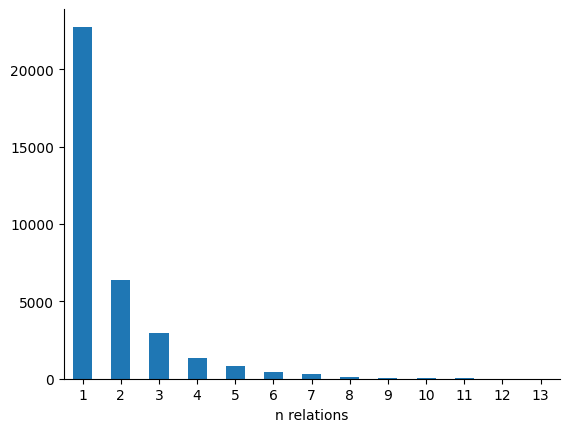

In [ ]:
ax = X.T.sum().sort_values().value_counts().sort_index().head(13).plot.bar(rot=0)
ax.set_xlabel("n relations")
sns.despine()
# plt.title("Counts of Relations Numbers")
plt.show()

### Extract ENSLAVED_PERSON and ENSLAVER

In [ ]:
# ENSLAVED_PERSON = X['wasEnslavedBy'].stack()
# ENSLAVED_PERSON = ENSLAVED_PERSON[ENSLAVED_PERSON > 0].to_frame('n')
# ENSLAVED_PERSON.index.names = ['person_key', 'enslaver_key']
# ENSLAVED_PERSON = ENSLAVED_PERSON.sort_index()
# ENSLAVED_PERSON['enslaved_key'] = ENSLAVED_PERSON.apply(lambda x: f"{x.name[0]}-{x.name[1]}", axis=1)
# ENSLAVED_PERSON.enslaved_key = ENSLAVED_PERSON.enslaved_key.str.replace(r"-xxxx-x-x-", "@", regex=True)
# ENSLAVED_PERSON

In [ ]:
# ENSLAVED_PERSON.loc['1851-b-m-x']

In [ ]:
# ENSLAVER = X['wasEnslavedBy'].T.sum(axis=1).sort_values(ascending=False).to_frame('n')
# ENSLAVER.index.name = 'person_id'
# ENSLAVER

### Create Interactive Tool

In [33]:
# PERSON.reset_index().merge(RELATION.reset_index(), left_on='person_key', right_on='subject_key', how='left')

In [40]:
MENTION.columns

Index(['source', 'source_year', 'confidence', 'full_name', 'first_name',
       'middle_name', 'last_name', 'birth_year', 'death_year', 'race',
       'gender', 'occupation', 'legal_status', 'is_enslaver',
       'norm_first_name', 'nysiis_last_name', 'norm_race', 'norm_occupation',
       'enslaver_id', 'location_id', 'head', 'household_id', 'family_id',
       'enslaver_name', 'person_key'],
      dtype='str')

In [51]:
# MENTION

In [67]:
person_auto_widget = widgets.Combobox(
    value=PERSON.sample().index[0],
    options=PERSON.index.to_list(),
    description='Person ID:',
    continuous_update=False
)
# all_mention_cols = MENTION.columns.to_list()
# cols_widget = widgets.SelectMultiple(
#     options=all_mention_cols,
#     value=['source_year', 'source', 'location_id'], # Default selected value
#     description='Columns:',
#     rows=len(all_mention_cols),
#     disabled=False
# )
@interact(person_id=person_auto_widget)
def view_person(person_id):
    mention_cols = ['source', 'source_year', 'household_id', 'family_id', 'location_id', 'norm_occupation']
    display(HTML(f"<h3>Person ID: {person_id.replace("_", " ").replace("-", " ").title()}</h3>"))
    try:
        person = PERSON.loc[person_id]
    except KeyError as e:
        display(HTML("<tt>Try again.</tt>"))
        return None
    test_ids = person.mention_ids
    display(MENTION.loc[test_ids].sort_values('source_year')[mention_cols].T.dropna().T)
    try:
        display(HTML("<hr />"))
        display(RELATION.loc[person_id])
    except KeyError as e:
        display(HTML("No relations found."))

interactive(children=(Combobox(value='1800-w-f-Xcy_michie', continuous_update=False, description='Person ID:',…

## Save

In [ ]:
MENTION.to_parquet("../data/MENTION.parquet", index=True)
ASSERTION.to_parquet("../data/ASSERTION.parquet", index=True)
PERSON.to_parquet("../data/PERSON.parquet", index=True)
RELATION.to_parquet("../data/RELATION.parquet", index=True)
# ENSLAVED_PERSON.to_parquet("../data/ENSLAVED_PERSON.parquet", index=True)
# ENSLAVER.to_parquet("../data/ENSLAVER.parquet", index=True)
A.to_parquet("../data/A.parquet", index=True)
X.to_parquet("../data/X_wide.parquet")

## Explore

### Distribution of Source Years

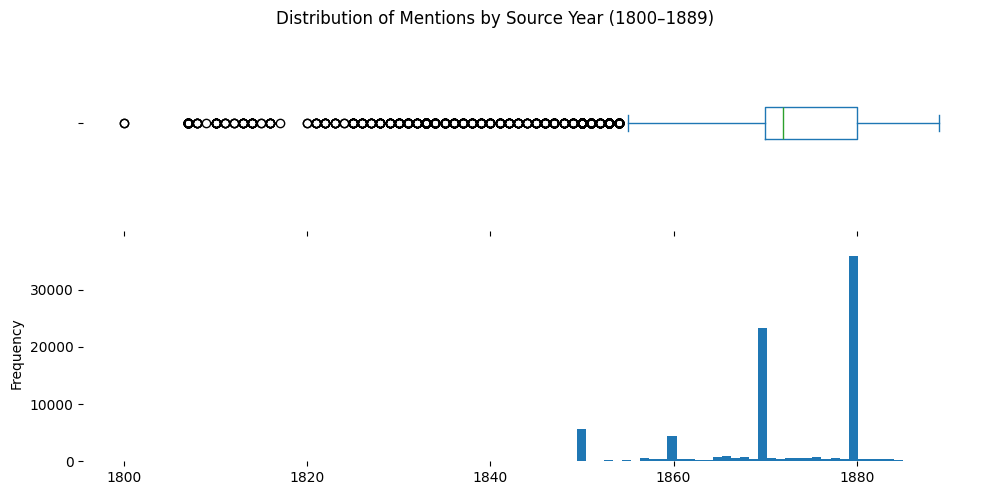

In [ ]:
date_range = (MENTION.source_year >= 1800) & (MENTION.source_year < 1890)
X = MENTION[date_range].source_year

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10,5))

X.plot.box(ax=axes[0], vert=False)
X.plot.hist(ax=axes[1], bins=90)

axes[0].set_yticklabels("")

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.suptitle("Distribution of Mentions by Source Year (1800–1889)")
plt.show()

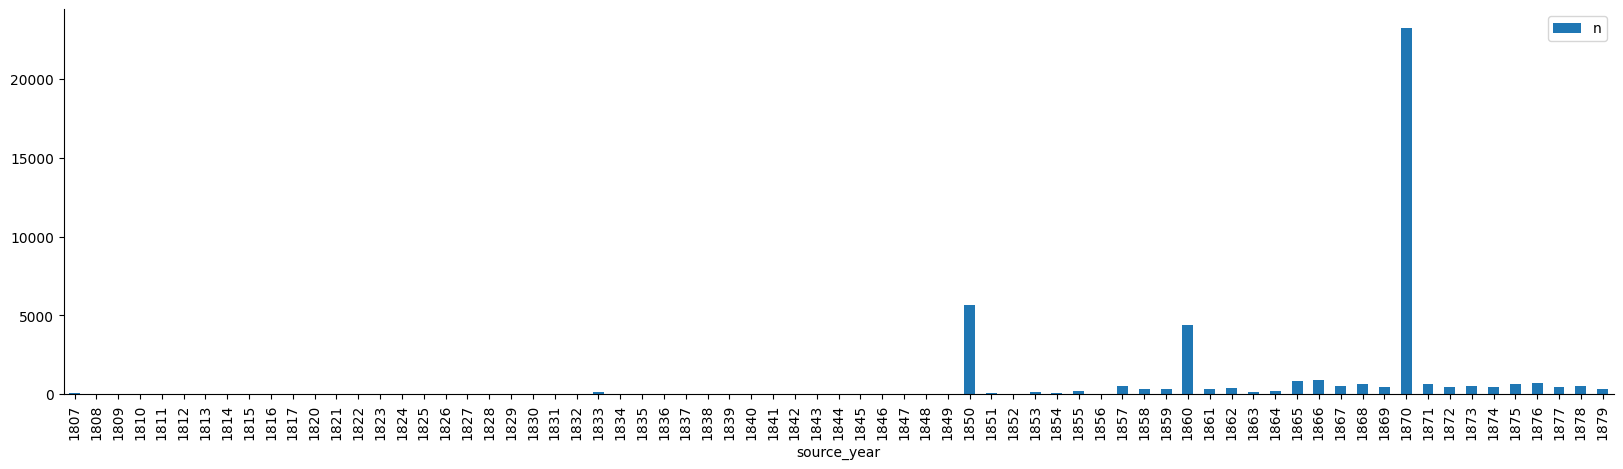

In [ ]:
(
    MENTION[(MENTION.source_year > 1800) & (MENTION.source_year < 1880)]
    .value_counts('source_year')
    .to_frame('n')
    .sort_index()
    .plot.bar(figsize=(20,5))
)
sns.despine()

### Distribution of Birth Years

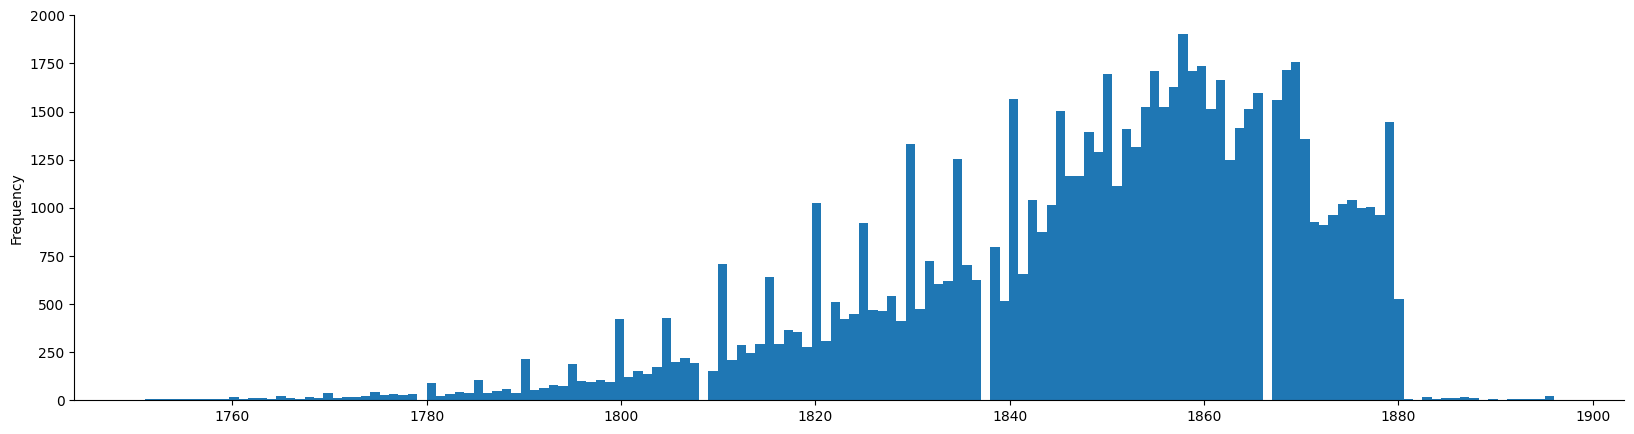

In [ ]:
MENTION[MENTION.birth_year > 1750].birth_year.plot.hist(bins=150, figsize=(20,5))
sns.despine()
plt.show()

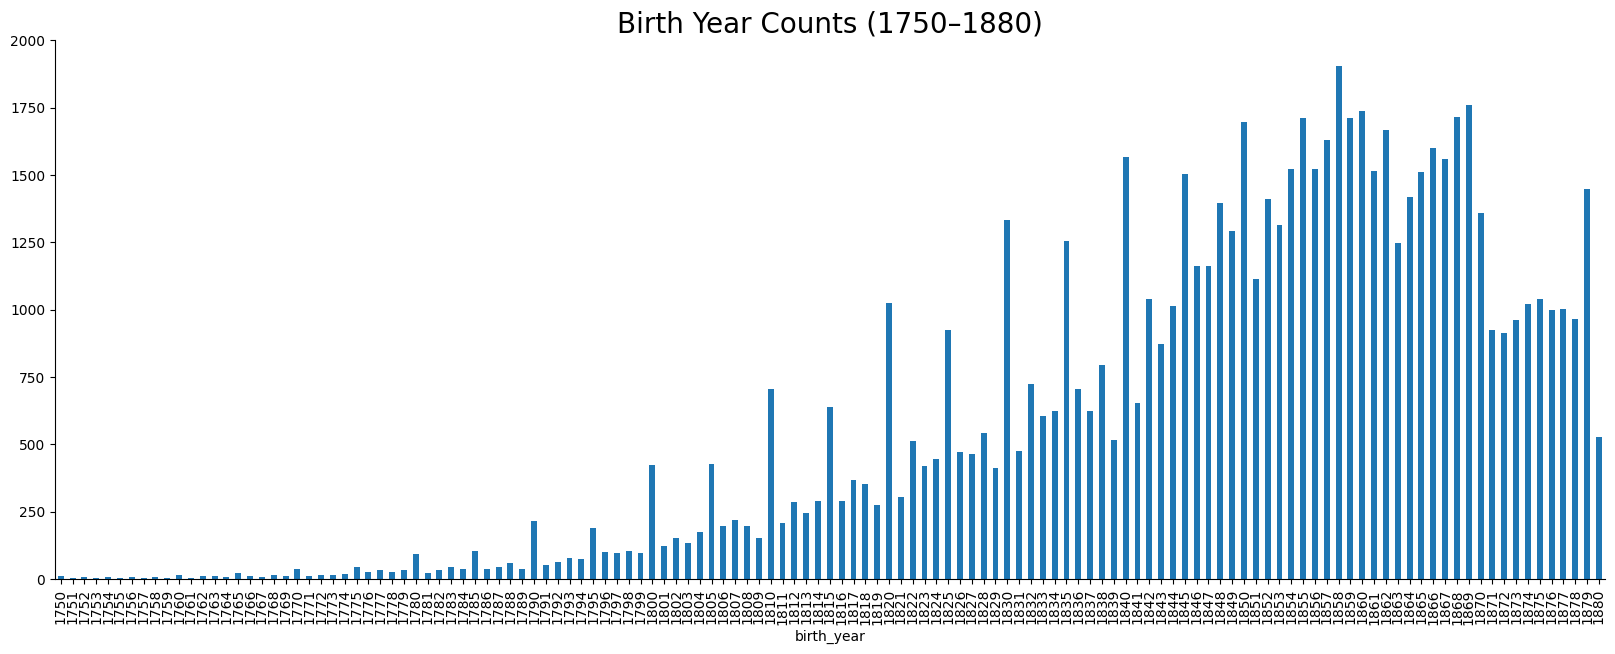

In [ ]:
X = MENTION[(MENTION.birth_year >= 1750) & (MENTION.birth_year < 1881)].birth_year.value_counts().sort_index()
X.plot.bar(x='birth_year', y='n', figsize=(20,7))
plt.title("Birth Year Counts (1750–1880)", fontsize=20)
sns.despine()
plt.show()

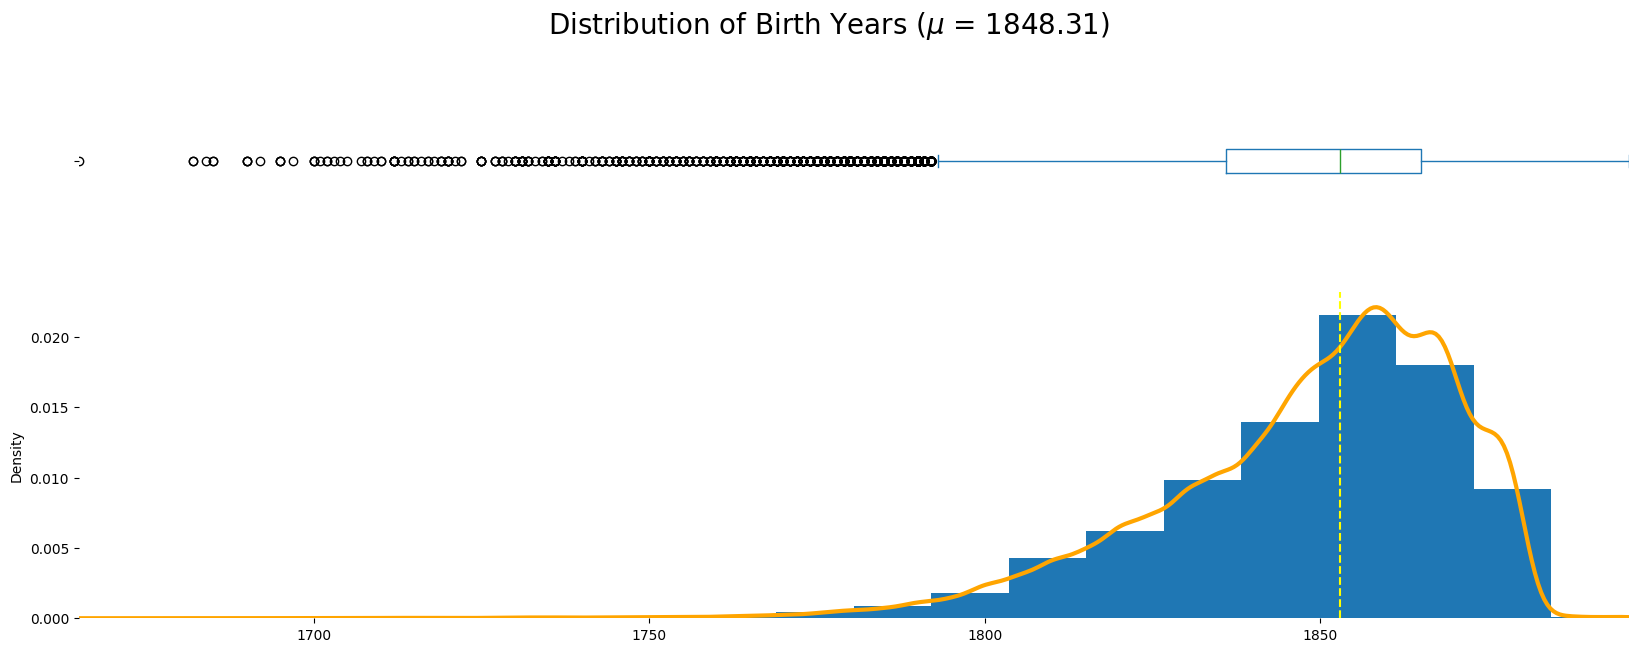

In [ ]:
X = MENTION.loc[MENTION.birth_year > 188, 'birth_year']

fig, axes = plt.subplots(2, 1, figsize=(20, 7), sharex=True,
    gridspec_kw={'height_ratios': [1, 2]})

X.plot.box(ax=axes[0], vert=False)
X.plot.hist(ax=axes[1], bins=20, density=True)
X.plot.kde(ax=axes[1], color='orange', lw=3)

axes[0].set_yticklabels([])
axes[0].tick_params(axis='x', which='both', bottom=False, labelbottom=False)
axes[1].axvline(X.median(), color='yellow', ls='--')
axes[0].set_xlim(X.min(), X.max())
axes[1].set_xlim(X.min(), X.max())

sns.despine(left=True, bottom=True)
plt.suptitle(rf"Distribution of Birth Years ($\mu$ = {MENTION.birth_year.mean().round(2)})", fontsize=20)
plt.show()